In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import datetime as dt
from IPython.display import display

In [2]:
airbnb = pd.read_csv('https://raw.githubusercontent.com/kflisikowsky/Descriptive_Statistics/refs/heads/main/data/airbnb.csv', index_col = 'Unnamed: 0')

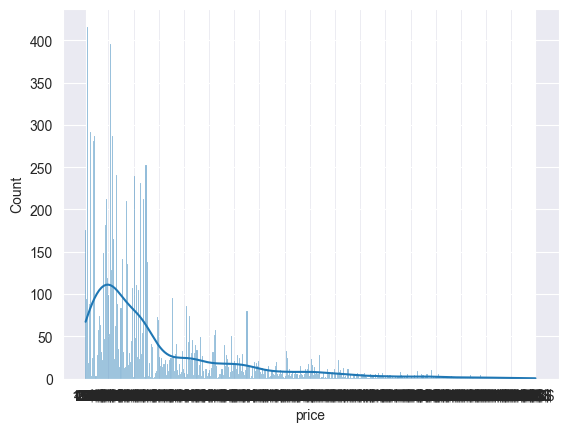

In [3]:
sns.histplot(airbnb['price'], kde = True, bins =20)
plt.show()

In [5]:
airbnb['price'] = airbnb['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# 2. Zamieniamy tekst na liczby.
# errors='coerce' sprawi, że jeśli zostanie jakiś dziwny tekst, którego nie da się zamienić na liczbę, zmieni się on w pustą wartość (NaN)
airbnb['price'] = pd.to_numeric(airbnb['price'], errors='coerce')

# 3. Filtrujemy dane (usuwamy zera, wartości ujemne oraz nowo powstałe NaN)
df_clean = airbnb[airbnb['price'] > 0].copy()
df_clean = df_clean.dropna(subset=['price'])

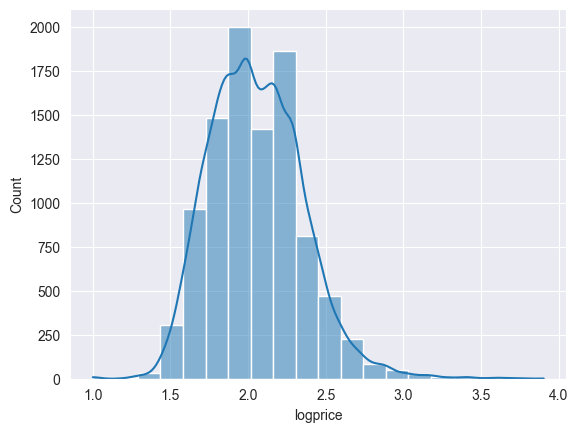

In [7]:
# 1. Filtrujemy oryginalną ramkę (zostawiamy tylko ceny > 0)
df_clean = airbnb[airbnb['price'] > 0].copy()

# 2. Liczymy logarytm na ODFILTROWANEJ ramce
df_clean['logprice'] = np.log10(df_clean['price'])

# 3. Rysujemy wykres używając ODFILTROWANEJ ramki
sns.histplot(df_clean['logprice'], kde=True, bins=20)
plt.show()

In [19]:
custom_bins = [0, 50, 100, 200, 1000, np.inf]

custom_labels = ['Very Cheap (0-50)', 'Cheap (50-100)', 'Average (100-200)', 'Expensive (200-1000)', 'Luxury (1000+)']

df_clean['custom_category'] = pd.cut(df_clean['price'], bins=custom_bins, labels=custom_labels)

summary_table = df_clean.groupby('custom_category', observed=False)['price'].agg(['min', 'max', 'count'])
summary_table.columns = ['Min Price', 'Max Price', 'Number of Listings']
summary_table.index.name = 'Segment'

display(summary_table)

,Min Price,Max Price,Number of Listings
Segment,,,
Very Cheap (0-50),10.0,50.0,1260
Cheap (50-100),51.0,100.0,3512
Average (100-200),101.0,200.0,3316
Expensive (200-1000),201.0,1000.0,1638
Luxury (1000+),1002.0,8000.0,53
